In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [3]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

### Complete Case Analysis (CCA) = You drop all rows that have any missing values and train your model only on the remaining “complete” data.

### ✅ When to use CCA

Use CCA only when these conditions are mostly true:

1. Missing data is MCAR (Missing Completely At Random)

The missing values have no pattern

Example: sensor randomly failed, survey skipped randomly

👉 If data is MCAR → removing rows does not bias your model

2. Very small percentage of missing values

Rule of thumb:
✔ less than 5%–10% missing data

👉 If you drop rows, you won’t lose much information

3. Large dataset

You have plenty of data even after dropping rows

👉 Example:

1,00,000 rows → losing 5,000 rows is okay

500 rows → losing 100 rows is risky ❌

4. Missing values spread across many columns (not concentrated)

If only 1 column has many missing values → better to impute

If few missing scattered → CCA is fine

5. When simplicity is important

Quick baseline model

No need for complex imputation

In [5]:
cols = [ var for var in df.columns if df[var].isnull().mean()*100 < 5 and df[var].isnull().mean()*100  > 0 ]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [7]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
13755,0.802,Full time course,Graduate,4.0,8.0
9896,0.910,no_enrollment,High School,11.0,42.0
5052,0.920,no_enrollment,Graduate,16.0,12.0
12403,0.920,no_enrollment,Graduate,3.0,19.0
11543,0.527,no_enrollment,Graduate,7.0,63.0


In [10]:
# now we will check if droping the data how much of data we will be left with 

len(df[cols].dropna())/len(df)

## the value that we got stses that we will be left with a good amount of data ie 89% of data after froping the nan values in the repective cols in cols

0.8968577095730244

In [13]:
## creating a new df 
df_new = df[cols].dropna()
df.shape,df_new.shape

((19158, 13), (17182, 5))

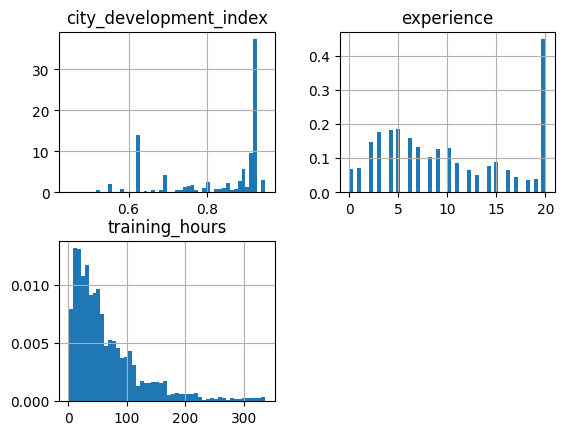

In [17]:
## plotting to see the distribution of the cols using a histogram

plt.Figure(figsize = (15,10))
# plt.subplot(121)
df[cols].hist(bins = 50 , density = True)
# plt.subplot(122)
# plt.t(df_new,bins = 50 , density = True)

plt.show()

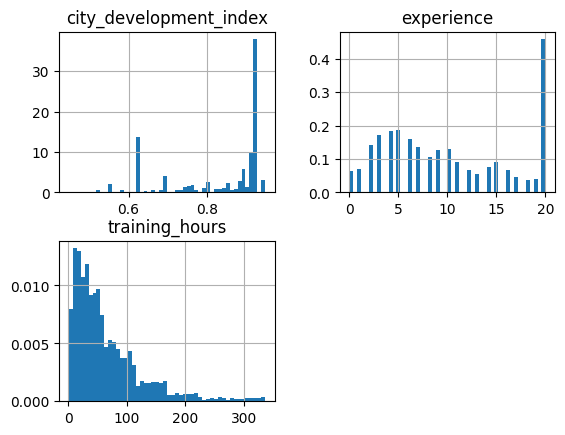

In [18]:
df_new.hist(bins=50 , density = True)

plt.show()

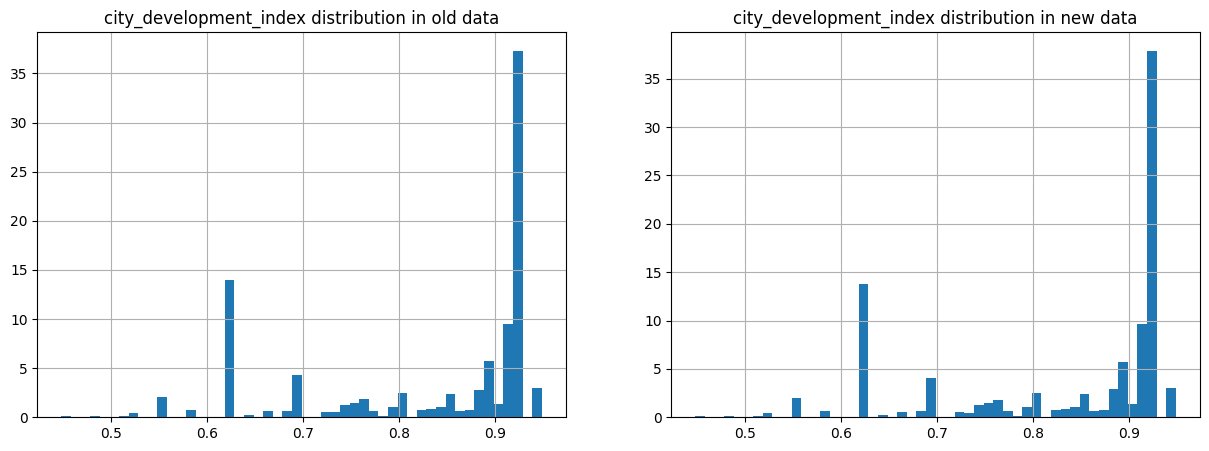

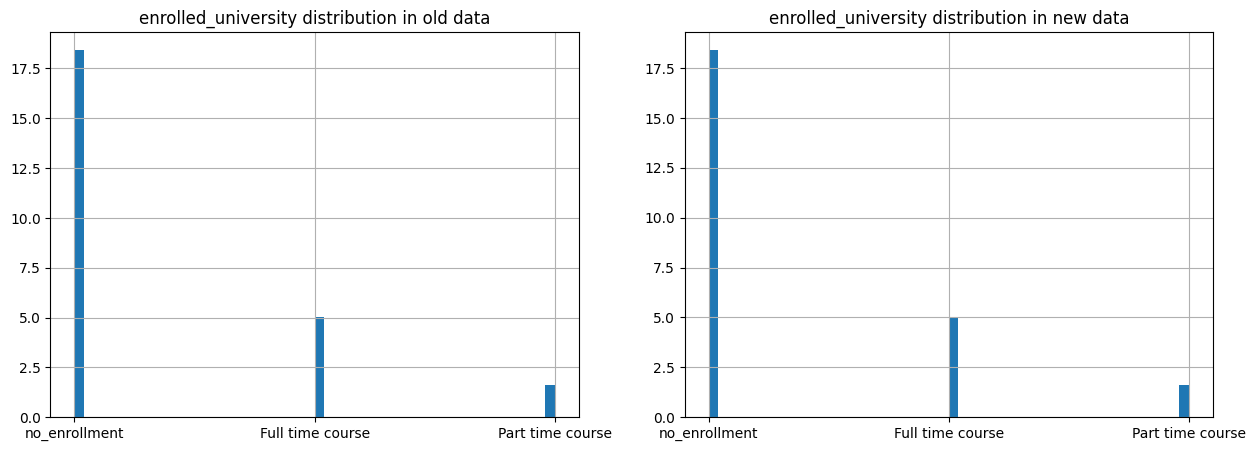

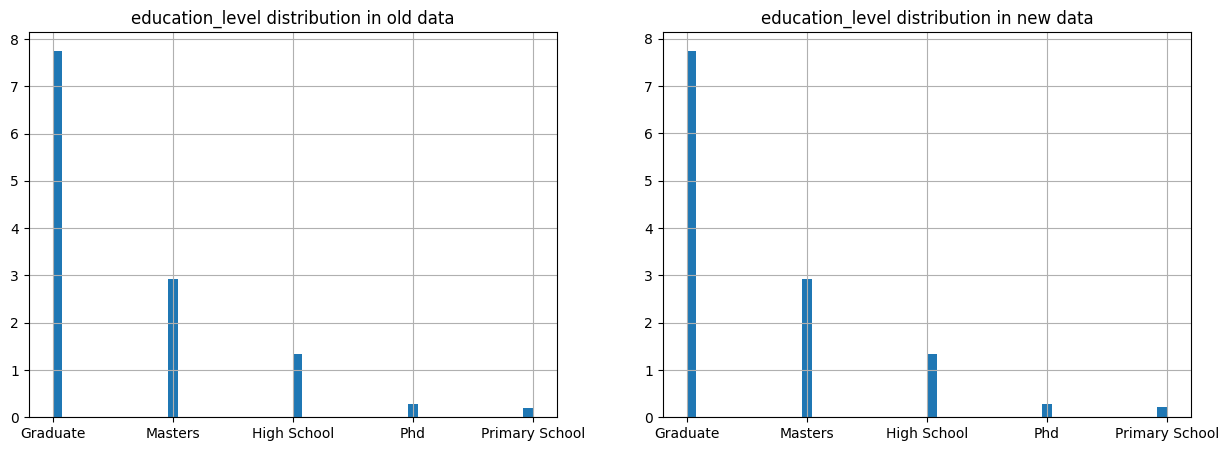

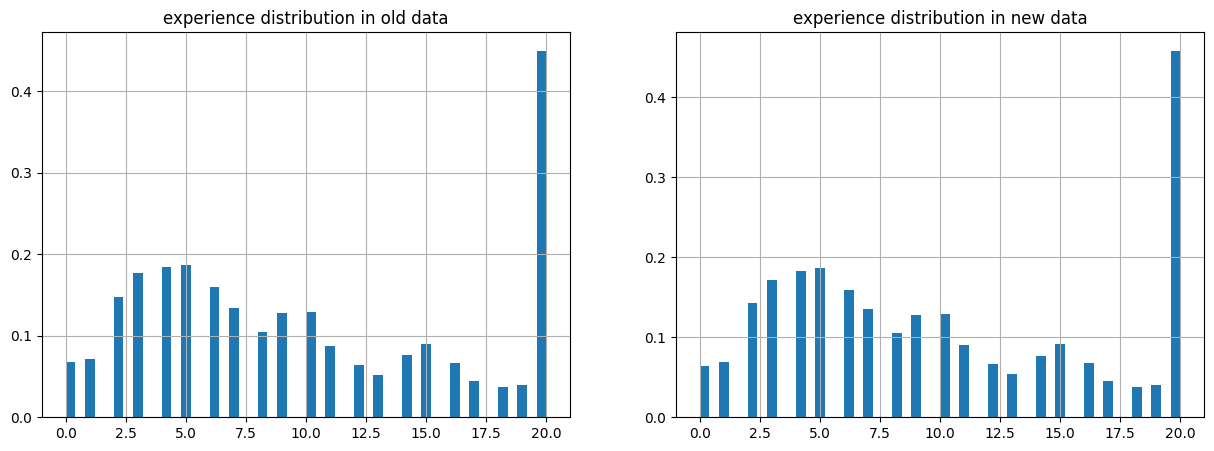

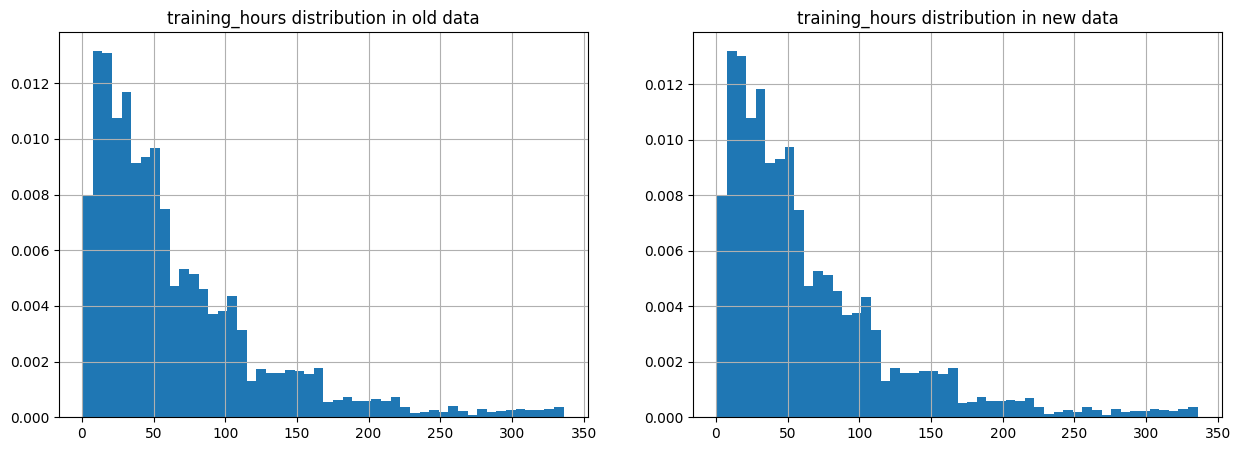

In [19]:
## now we will see the cols wise comparison of data between new and old data

for col in cols:
    plt.figure(figsize = (15,5))
    plt.subplot(121)
    df[col].hist(bins = 50 , density = True)
    plt.title(f'{col} distribution in old data')
    plt.subplot(122)
    df_new[col].hist(bins = 50 , density = True)
    plt.title(f'{col} distribution in new data')
    plt.show()


 Col =  city_development_index


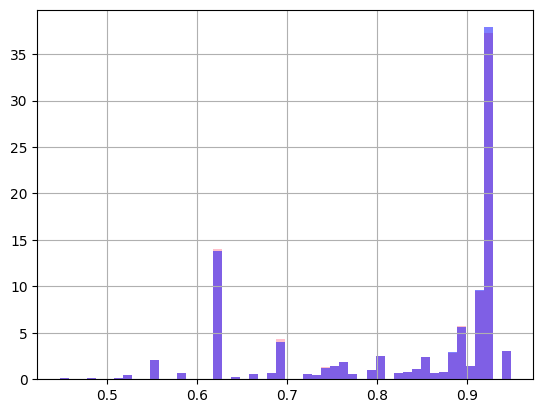

 Col =  enrolled_university


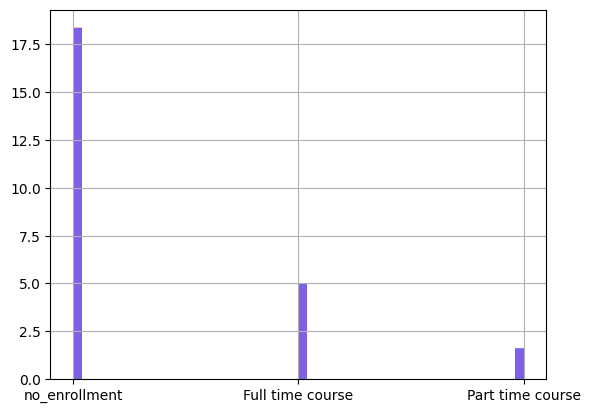

 Col =  education_level


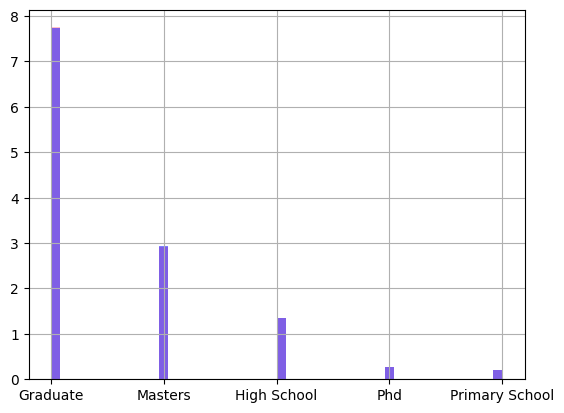

 Col =  experience


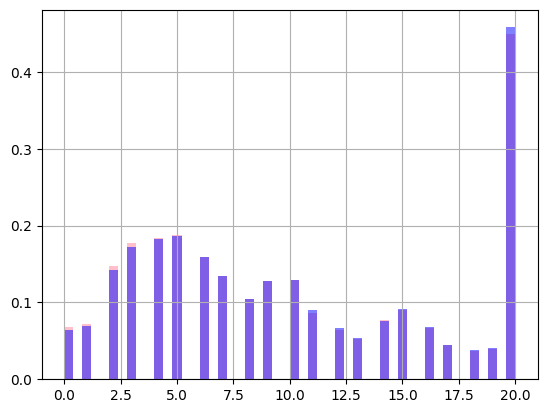

 Col =  training_hours


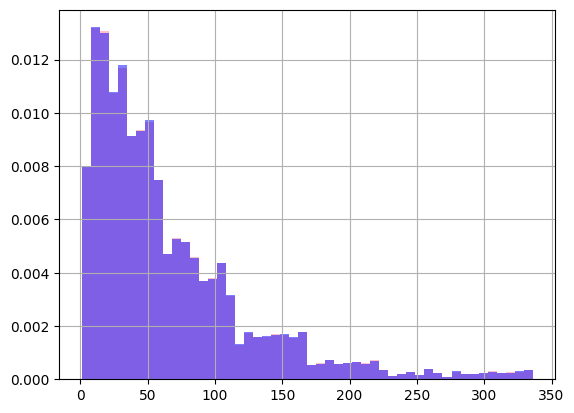

In [24]:
# now we will plot the add_subplot to see the distribution of the cols in old and new data side by side

# fig = plt.figure()
# ax = fig.add_subplot(111)

for col in cols:
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    print(" Col = ",col)
    df[col].hist(bins = 50,density=True, ax = ax, color = 'pink')
    df_new[col].hist(bins = 50,density=True, ax = ax, alpha = 0.5, color= 'blue') 
    plt.show()
    



In [27]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [31]:
## For categorical data we can also check by finding the ratios  if the ratio is not much different then we can say that the data is missing at random and we can drop the data without much loss of information

print(df['education_level'].value_counts())
print()
print("Above is the before droping the data and below is after droping the data")
print()
print(df_new['education_level'].value_counts())

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

Above is the before droping the data and below is after droping the data

education_level
Graduate          10650
Masters            4022
High School        1845
Phd                 380
Primary School      285
Name: count, dtype: int64


In [ ]:
## ratios 
print(len(df_new['education_level'])/len(df['education_level']))

# not much differeence

0.8968577095730244


In [33]:
col_cate  = ['enrolled_university',
 'education_level']
for col in col_cate:
    print(f"Col = {col}")
    print(df[col].value_counts())
    print()
    print("Above is the before droping the data and below is after droping the data")
    print()
    print(df_new[col].value_counts())
    print()
    print("Ratios = ",len(df_new[col])/len(df[col]))
    print("-"*50)

Col = enrolled_university
enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

Above is the before droping the data and below is after droping the data

enrolled_university
no_enrollment       12632
Full time course     3449
Part time course     1101
Name: count, dtype: int64

Ratios =  0.8968577095730244
--------------------------------------------------
Col = education_level
education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

Above is the before droping the data and below is after droping the data

education_level
Graduate          10650
Masters            4022
High School        1845
Phd                 380
Primary School      285
Name: count, dtype: int64

Ratios =  0.8968577095730244
--------------------------------------------------


In [ ]:
# hence this # the changes that was made after the data was droped is not much and the distribution of the data is also not much different so we can say that the data is missing at random and we can drop the data without much loss of information